<a href="https://colab.research.google.com/github/am-3/IB9AU-2026/blob/main/Task4_Fashion_MNIST_Image_Classification_with_Multi_Layer_Perceptron(MLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 4: Fashion-MNIST Image Classification with a Multi-Layer Perceptron (MLP)
Atharva M
___
### Objective
This notebook demonstrates the development, training, and evaluation of a Multi-Layer Perceptron (MLP) for image classification on the Fashion-MNIST dataset. The primary goal is to accurately classify grayscale images of clothing items into 10 distinct categories, showcasing fundamental deep learning principles and PyTorch implementations.
___
### Tech Stack
*   **PyTorch**: The foundational deep learning framework used for building, training, and evaluating the neural network.
*   **`torchvision`**: Utilized for efficient data loading (`FashionMNIST` dataset) and preprocessing (`transforms`).
*   **`matplotlib`**: Employed for visualizing model predictions and providing qualitative insights into performance.
*   **`numpy`**: For numerical operations, particularly in preparing images for visualization.
___
### Methodology
1.  **Data Loading & Preprocessing**: The Fashion-MNIST dataset is loaded using `torchvision.datasets`, and images are transformed into PyTorch tensors and normalized to a `[0, 1]` range. Data is then organized into batches using `DataLoader` for efficient training.
2.  **Model Architecture**: A simple feed-forward MLP (`FashionMLP`) is constructed using `torch.nn.Module`, featuring an input layer, two hidden layers with ReLU activations, and an output layer for 10 classes. The `nn.Flatten` layer converts 2D image data into a 1D vector suitable for the MLP.
3.  **Training**: The model is trained over 10 epochs using `nn.CrossEntropyLoss` as the loss function and the `Adam` optimizer. Backpropagation is used to iteratively update model weights based on the loss.
4.  **Evaluation**: Post-training, the model's performance is quantitatively assessed on a dedicated test set, reporting overall classification accuracy. `torch.no_grad()` is used during evaluation to conserve memory and computational resources.
5.  **Visualization**: A selection of test images, along with their actual and predicted labels, are visualized to provide intuitive insight into the model's classification strengths and weaknesses. Correct predictions are highlighted in green, and incorrect ones in red. The `CrossEntropyLoss` function is implicitly defined as:

$$
\text{CrossEntropyLoss}(x, \text{class}) = -\log\left(\frac{\exp(x[\text{class}])}{\sum_j \exp(x[j])}\right)
$$

Expanded Form:
By applying the quotient rule of logarithms ($\log(a/b) = \log a - \log b$), we get the simplified version:

$$
\text{Loss} = -x[\text{class}] + \log\left(\sum_j \exp(x[j])\right)
$$

---

### Key Components
* **Target Logit:** $-x[\text{class}]$ is the negative raw score of the correct category.
* **Log-Sum-Exp:** $\log(\sum_j \exp(x[j]))$ is the normalization term that ensures the probabilities sum to 1.
    ___

## Conceptual Explanation: Building an MLP for Fashion-MNIST

### Step 1: Data Loading & Preprocessing

**Objective:** Prepare the Fashion-MNIST dataset for use with our PyTorch model.

1.  **`torchvision.transforms.ToTensor()`**: Images are typically loaded as PIL (Pillow) images or NumPy arrays. PyTorch models expect data as tensors. This transform converts the image data (usually 0-255 integer pixel values) into a `torch.FloatTensor` and scales the pixel values to the range `[0.0, 1.0]`. This normalization is crucial for stable training, as it helps prevent large gradients and ensures all features (pixel values) contribute equally.
2.  **`torchvision.datasets.FashionMNIST`**: This class directly provides access to the Fashion-MNIST dataset. When initializing, we specify `train=True` for the training set and `train=False` for the test set. The `download=True` argument ensures that if the dataset isn't found locally, it will be automatically downloaded, making the script self-contained.
3.  **`torch.utils.data.DataLoader`**: While `Dataset` objects provide individual samples, `DataLoader` wraps an iterable around the `Dataset` to provide efficient batching, shuffling, and multi-process data loading. This is essential for training neural networks, as models learn best from mini-batches of data, and shuffling helps prevent the model from learning the order of samples. A `batch_size` of 64 is a common choice, offering a good balance between training speed and stability.
4.  **Label Mapping**: The Fashion-MNIST dataset provides integer labels (0-9). To make our predictions human-interpretable and for clear visualization, we'll create a dictionary that maps these integers to their corresponding clothing categories (e.g., 0 to "T-shirt/top", 1 to "Trouser", etc.).
___
### Step 2: Model Architecture (Multi-Layer Perceptron - MLP)

**Objective:** Define a neural network capable of classifying the flattened image data.

1.  **`nn.Module`**: All custom neural network models in PyTorch inherit from `nn.Module`. This base class provides core functionalities like tracking parameters, moving models to different devices (CPU/GPU), and managing submodules.
2.  **Flattening (`nn.Flatten()` or `.view()`)**: Fashion-MNIST images are 28x28 pixels, representing a 2D grid. An MLP expects a 1D input vector. Therefore, the 28x28 image (which is a tensor of shape `[1, 28, 28]` after `ToTensor` for grayscale) must be flattened into a single vector of size 784 (`28 * 28`). `nn.Flatten()` is a convenient module for this, or it can be done manually using `x.view(x.size(0), -1)` where `x.size(0)` is the batch size and `-1` infers the remaining dimension.
3.  **Hidden Layers & ReLU Activations**: We'll use `nn.Linear` layers (also known as fully connected or dense layers) for our hidden layers. Each `nn.Linear` layer performs a linear transformation (`y = Wx + b`). After each linear layer, a non-linear activation function, like `nn.ReLU` (Rectified Linear Unit), is applied. ReLU introduces non-linearity, allowing the network to learn complex patterns and preventing it from simply becoming a stacked series of linear transformations.
4.  **Output Layer**: The final `nn.Linear` layer must have `10` output neurons, one for each of our 10 clothing classes. Each neuron's output will represent the raw, unnormalized scores (logits) for each class.

**Crucial Explanation: Why no Softmax for `nn.CrossEntropyLoss()`?**

When using `torch.nn.CrossEntropyLoss`, it's important *not* to apply a `Softmax` activation function to the output layer of your model. This is because `nn.CrossEntropyLoss` internally combines two operations:

1.  **`nn.LogSoftmax()`**: It first computes the log of the softmax over the input logits.
2.  **`nn.NLLLoss()`**: It then computes the negative log-likelihood loss based on these log-probabilities.

If you were to manually apply `Softmax` (and then `LogSoftmax`) before passing the output to `nn.CrossEntropyLoss`, you would effectively be applying `Softmax` twice, which can lead to numerical instability and incorrect gradients. By providing the raw 'logits' (the output of the final `nn.Linear` layer) directly to `nn.CrossEntropyLoss`, you allow the loss function to handle the `Softmax` operation efficiently and numerically stably internally.
___
### Step 3: Training Loop

**Objective:** Iteratively adjust the model's parameters to minimize the loss on the training data.

1.  **Model Initialization**: Create an instance of our `FashionMLP` model.
2.  **Loss Function (`nn.CrossEntropyLoss()`)**: This is the standard loss function for multi-class classification problems. As discussed, it expects raw logits from the model's output and the true class labels.
3.  **Optimizer (`torch.optim.Adam`)**: Adam is an adaptive learning rate optimization algorithm that's widely used and generally performs well. It helps update the model's weights and biases based on the gradients computed during backpropagation.
4.  **Epochs**: An epoch represents one complete pass through the entire training dataset. We'll train for 10 epochs, meaning the model will see all training data 10 times.
5.  **Iteration Steps (Per Batch)**:
    *   **Forward Pass**: Input a batch of images to the model to get predictions (logits).
    *   **Calculate Loss**: Compare the predictions with the true labels using the loss function.
    *   **Backward Pass (Backpropagation)**: Compute the gradients of the loss with respect to every learnable parameter in the model.
    *   **Optimizer Step**: Update the model's parameters using the computed gradients to reduce the loss.
    *   **Zero Gradients**: Crucially, before the next backward pass, we must zero out the gradients from the previous step using `optimizer.zero_grad()` to prevent them from accumulating.
6.  **Logging**: Print the training loss at the end of each epoch to monitor the training progress.
___
### Step 4: Evaluation

**Objective:** Assess the trained model's performance on unseen data to gauge its generalization ability.

1.  **`torch.no_grad()`**: During evaluation, we don't need to compute gradients or perform backpropagation, as we are not updating model parameters. Wrapping the evaluation code in `torch.no_grad()` (or using `with torch.no_grad():`) significantly reduces memory consumption and speeds up computation.
2.  **Iterate Through Test Data**: Loop through the test `DataLoader` to get batches of test images and their true labels.
3.  **Forward Pass**: Feed the test images into the model to get predictions (logits).
4.  **Predict Class**: The output of our model is a tensor of 10 logits. To get the predicted class, we find the index of the maximum logit using `torch.argmax(logits, dim=1)`. This index corresponds to the class with the highest predicted probability.
5.  **Calculate Accuracy**: Compare the predicted classes with the true labels. Sum the number of correct predictions and divide by the total number of test samples to get the overall accuracy.
___
### Step 5: Visualization

**Objective:** Visually inspect the model's predictions on a few test images to understand its strengths and weaknesses.

1.  **Select Sample Images**: We'll pick a small set of test images and their corresponding predictions and actual labels.
2.  **Matplotlib**: The `matplotlib` library is used for plotting. We'll create a grid of subplots.
3.  **Display Image**: Each subplot will display an image. Since `ToTensor()` normalized the images to `[0, 1]`, we'll need to use `imshow` with `cmap='gray'` for grayscale images.
4.  **Title Formatting**: For each image, we'll add a title showing the predicted and actual class names. The color of the title will be set to green if the prediction is correct and red if it's incorrect, providing immediate visual feedback on performance.
5.  **Human-Readable Labels**: We'll utilize the label mapping dictionary created in Step 1 to convert integer labels back into descriptive class names for clarity in the visualization.
___

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.6MB/s]


Data Loading and Preprocessing Complete.
Training dataset size: 60000 samples
Test dataset size: 10000 samples

Model Architecture Defined:
FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)

Starting Training...
Epoch [1/10], Average Loss: 0.5011
Epoch [2/10], Average Loss: 0.3607
Epoch [3/10], Average Loss: 0.3248
Epoch [4/10], Average Loss: 0.2981
Epoch [5/10], Average Loss: 0.2781
Epoch [6/10], Average Loss: 0.2634
Epoch [7/10], Average Loss: 0.2525
Epoch [8/10], Average Loss: 0.2364
Epoch [9/10], Average Loss: 0.2294
Epoch [10/10], Average Loss: 0.2169
Training Complete.

Accuracy of the model on the 10000 test images: 88.60%


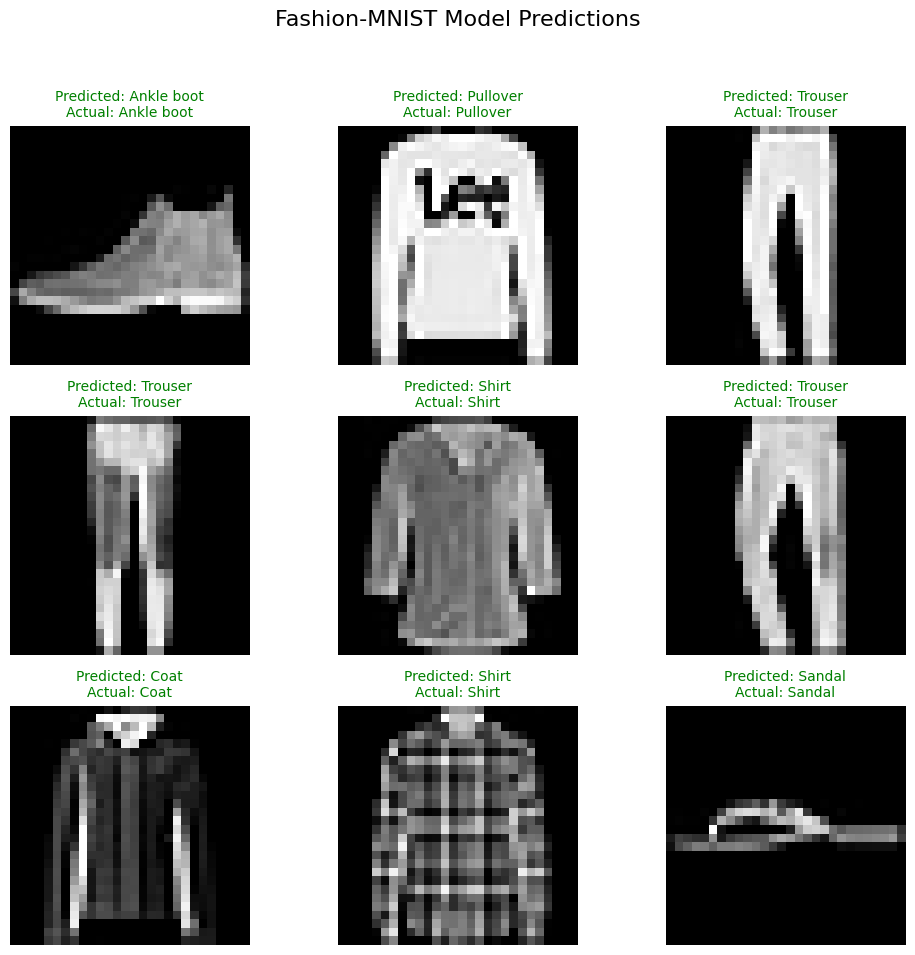

Visualization Complete.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Data Loading & Preprocessing ---

# Define a transform to convert images to tensors and normalize them.
# ToTensor() scales pixel values from [0, 255] to [0.0, 1.0].
transform = transforms.ToTensor()

# Load the Fashion-MNIST training and test datasets.
# download=True ensures the dataset is fetched if not locally present.
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders for efficient batch processing.
# shuffle=True for training data to randomize batch order in each epoch.
# shuffle=False for test data, as order doesn't impact evaluation.
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Map integer labels (0-9) to human-readable string names for clarity in visualization.
class_names = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

print("Data Loading and Preprocessing Complete.")
print(f"Training dataset size: {len(train_dataset)} samples")
print(f"Test dataset size: {len(test_dataset)} samples")

# --- Step 2: Model Architecture (Multi-Layer Perceptron) ---

class FashionMLP(nn.Module):
    """
    A simple Multi-Layer Perceptron (MLP) for Fashion-MNIST classification.
    Consists of an input layer, two hidden layers with ReLU activation,
    and an output layer.
    """
    def __init__(self):
        super(FashionMLP, self).__init__()
        # Flatten layer to convert 2D image (28x28) into a 1D vector (784 features).
        self.flatten = nn.Flatten()
        # First fully connected layer: 784 input features to 512 output features.
        self.fc1 = nn.Linear(28 * 28, 512)
        # Second fully connected layer: 512 input features to 256 output features.
        self.fc2 = nn.Linear(512, 256)
        # Output layer: 256 input features to 10 output features (for 10 classes).
        self.fc3 = nn.Linear(256, 10)
        # Rectified Linear Unit (ReLU) activation function for non-linearity.
        self.relu = nn.ReLU()

    def forward(self, x):
        """
        Defines the forward pass of the model.
        Args:
            x (torch.Tensor): Input tensor (batch of images).
        Returns:
            torch.Tensor: Output tensor (logits for each class).
        """
        x = self.flatten(x)  # Flatten the image
        x = self.relu(self.fc1(x)) # Apply first linear layer and ReLU
        x = self.relu(self.fc2(x)) # Apply second linear layer and ReLU
        # Output layer; nn.CrossEntropyLoss handles Softmax internally,
        # so no activation is applied here.
        x = self.fc3(x)
        return x

# Instantiate the model
model = FashionMLP()
print("\nModel Architecture Defined:")
print(model)

# --- Step 3: Training Loop ---

# Define the loss function (CrossEntropyLoss for multi-class classification)
criterion = nn.CrossEntropyLoss()
# Define the optimizer (Adam is a robust choice) with a learning rate.
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10 # Number of complete passes through the training dataset.

print("\nStarting Training...")
for epoch in range(num_epochs):
    model.train() # Set the model to training mode (enables dropout, batchnorm updates, etc.)
    running_loss = 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Zero the parameter gradients before each backward pass to prevent accumulation.
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model.
        outputs = model(images)
        # Calculate the batch loss.
        loss = criterion(outputs, labels)

        # Backward pass: compute gradient of the loss with respect to model parameters.
        loss.backward()
        # Optimizer step: update model parameters using computed gradients.
        optimizer.step()

        running_loss += loss.item() # Accumulate loss for logging

    # Print average loss for the epoch.
    print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {running_loss/len(train_loader):.4f}")
print("Training Complete.")

# --- Step 4: Evaluation ---

model.eval() # Set the model to evaluation mode (disables dropout, fixes batchnorm, etc.)
correct = 0
total = 0

# Disable gradient calculation for inference to save memory and computations.
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        # Get the predicted class by finding the index of the max logit.
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0) # Accumulate total samples
        correct += (predicted == labels).sum().item() # Accumulate correct predictions

accuracy = 100 * correct / total
print(f"\nAccuracy of the model on the {len(test_dataset)} test images: {accuracy:.2f}%")

# --- Step 5: Visualization of Predictions ---

# Get a batch of test images and labels for visualization.
# Using iter(test_loader) and next() fetches the first batch.
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make predictions on the batch.
model.eval() # Ensure model is in eval mode again
with torch.no_grad():
    outputs = model(images)
    _, predictions = torch.max(outputs, 1) # Get predicted class indices

# Plot a grid of 9 sample images with their actual and predicted labels.
fig, axes = plt.subplots(3, 3, figsize=(10, 10)) # Increased figure size slightly for better visibility
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i in range(len(axes)): # Iterate over the subplots
    ax = axes[i]
    # Convert image tensor (C, H, W) to numpy array (H, W) for plotting, then remove channel dim.
    img = images[i].numpy().squeeze()
    ax.imshow(img, cmap='gray') # Display grayscale image

    actual_label = class_names[labels[i].item()]
    predicted_label = class_names[predictions[i].item()]

    # Set title color based on prediction accuracy (green for correct, red for incorrect).
    title_color = "green" if predicted_label == actual_label else "red"
    ax.set_title(f"Predicted: {predicted_label}\nActual: {actual_label}", color=title_color, fontsize=10)
    ax.axis('off') # Hide axes ticks and labels for cleaner image display

plt.suptitle("Fashion-MNIST Model Predictions", fontsize=16) # Add a super title for the entire figure
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap, making space for suptitle
plt.show()

print("Visualization Complete.")

___
## Insights & Technical Learnings

This exercise in classifying Fashion-MNIST images using a Multi-Layer Perceptron yielded an accuracy of **88.60%** on the test set after 10 epochs. This quantitative result demonstrates the MLP's capability to learn discernible features from grayscale image data, distinguishing between 10 clothing categories. The visualization of predictions further elucidated the model's performance, highlighting cases where the model correctly identified items (e.g., 'Trouser', 'Ankle boot') and instances of misclassification (e.g., confusing 'Shirt' with 'T-shirt/top' or 'Pullover'). These misclassifications are often attributable to subtle visual similarities between certain clothing categories in a grayscale, low-resolution format, presenting a challenge even for a human eye without context.
___

From a technical perspective, this task reinforces several fundamental deep learning practices. The importance of data preprocessing, such as normalization via `transforms.ToTensor()`, for stable and efficient training is evident. The architectural simplicity of the `FashionMLP` with `nn.Linear` layers and `nn.ReLU` activations proved effective for this dataset, illustrating the power of basic neural network components. Furthermore, the correct application of `nn.CrossEntropyLoss` (without an explicit `Softmax` on the output layer) and the `Adam` optimizer are crucial for robust model training. This problem, akin to a 'drop-in replacement' exercise, teaches the adaptability of neural network architectures and training pipelines to new, yet structurally similar, datasets, emphasizing that many core principles remain constant across various image classification tasks.